## Volatility Analysis

### Research Question

How does Bitcoin's volatility evolve over time, and what does it reveal about market risk?

### Research Objectives

By the end of this notebook, you will be able to:

Measure historical volatility.
Compute rolling volatility.
Identify volatility clustering.
Interpret changes in market risk over time.
Why This Matters

Volatility is the most widely used measure of financial risk. It plays a central role in portfolio management, derivative pricing, risk management, and quantitative trading.

In [5]:
TICKER = "BTC-USD"

START_DATE = "2020-01-01"
END_DATE = "2026-06-20"

INTERVAL = "1d"

AUTO_ADJUST = True

REFRESH_CACHE = True

In [4]:
import matplotlib.pyplot as plt

from asset_pricing_lab.returns import arithmetic_returns
from asset_pricing_lab.risk import historical_volatility, rolling_volatility
from crypto_alpha_lab.data.storage import load_prices

In [9]:
btc = load_prices(
    ticker=TICKER,
    start=START_DATE,
    end=END_DATE,
    interval=INTERVAL,
    auto_adjust=AUTO_ADJUST,
    refresh=REFRESH_CACHE,
)

simple_returns = arithmetic_returns(btc["Close"])

In [10]:
daily_volatility = historical_volatility(simple_returns)

print(f"Daily Volatility: {daily_volatility:.4f}")

Daily Volatility: 0.0315


In [11]:
# 30 days Rolling Volatility

rolling_vol = rolling_volatility(
    simple_returns,
    window=30,
)
rolling_vol

Date
2020-01-31    0.028623
2020-02-01    0.027682
2020-02-02    0.026691
2020-02-03    0.026810
2020-02-04    0.027024
                ...   
2026-06-15    0.021953
2026-06-16    0.021963
2026-06-17    0.022086
2026-06-18    0.022318
2026-06-19    0.022344
Name: Rolling Volatility, Length: 2332, dtype: float64

### Why 30 Days?

A 30-day rolling window is commonly used to estimate short-term market risk while smoothing out daily noise.

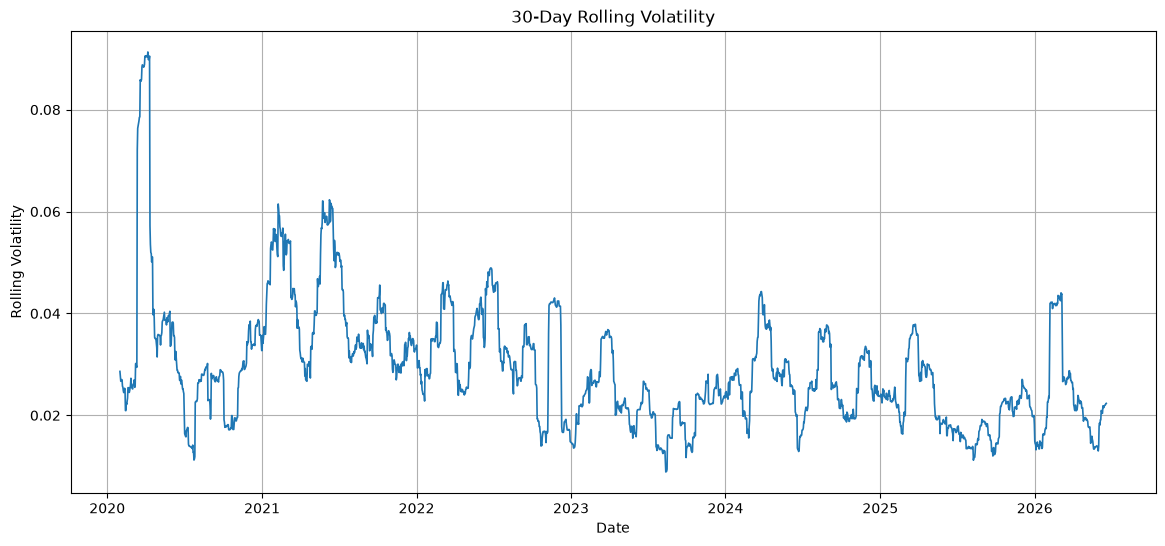

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_vol.index,
    rolling_vol,
    linewidth=1.2,
)

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")

plt.grid(True)

plt.show()

### Notebook Discussion

Rolling volatility demonstrates that Bitcoin's market risk changes over time rather than remaining constant. The presence of sustained high- and low-volatility periods indicates that market uncertainty is persistent and should be modeled dynamically.

### Rolling Volatility Interpretation

The 30-day rolling volatility plot shows that Bitcoin's risk changes significantly over time rather than remaining constant. Volatility reaches its highest levels during early 2020 and again throughout parts of 2021, indicating periods of heightened market uncertainty and large price fluctuations.

From 2022 onward, volatility generally declines, although several short-lived spikes remain visible. These recurring peaks demonstrate that periods of high market risk tend to cluster together rather than occur randomly, a phenomenon known as **volatility clustering**.

Overall, the chart confirms that Bitcoin exhibits **time-varying volatility**, with alternating periods of elevated and subdued market risk. This behavior suggests that assuming constant variance is inappropriate and supports the use of dynamic volatility models such as ARCH and GARCH in quantitative financial analysis.